<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 1 — Introducción con PhysioNet</font></h1>
<br>
<br>
<div style="text-align:right">
<!--<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>-->
<font color="#7F000E" size=3> Nivel: Ingeniería Biomédica — 7.º ciclo / 4.º año </font><br>
<font color="#7F000E" size=3> Modalidad: Jupyter Notebook / Google Colab </font><br>
<font color="#7F000E" size=3> Tema: Importación, exploración, visualización y exportación de ECG </font><br>
</div>

---

## Objetivos

Al finalizar este laboratorio, el estudiante será capaz de:

1. Acceder a una base de datos de señales fisiológicas de PhysioNet.
2. Cargar un registro ECG mediante la librería `wfdb`.
3. Identificar la frecuencia de muestreo, número de canales, nombres de canales y duración.
4. Construir el eje temporal de una señal discreta.
5. Visualizar una señal ECG mediante diferentes representaciones.
6. Analizar un segmento de la señal.
7. Exportar un segmento ECG a formato `.wav`.
8. Interpretar las diferencias entre una señal biomédica y una señal de audio.
9. Formular observaciones básicas sobre la morfología y amplitud de un ECG.

> **Importante:** el archivo WAV generado es una representación de la señal ECG en un formato reproducible por herramientas de audio. No significa que el ECG sea originalmente una señal acústica.



## 1. Introducción

Las señales biomédicas son señales generadas por procesos fisiológicos. Algunos ejemplos son:

- ECG — electrocardiograma
- EEG — electroencefalograma
- EMG — electromiograma
- EOG — electrooculograma
- PPG — fotopletismografía

En este laboratorio trabajaremos con una señal **ECG real** obtenida de **PhysioNet**.

PhysioNet proporciona acceso a numerosas bases de datos fisiológicas. Una de las bases más conocidas es la **MIT-BIH Arrhythmia Database**, que contiene registros electrocardiográficos anotados.

### Concepto fundamental: DATABASE + RECORD

Un registro no debe identificarse solamente por su número.

Por ejemplo:

```python
DATABASE = "mitdb"
RECORD = "100"
```

significa que estamos solicitando el registro `100` de la base de datos `mitdb`.

El mismo número de registro puede tener un significado diferente si pertenece a otra base de datos. Por ello, siempre debemos interpretar:

```text
BASE DE DATOS + RECORD
```

como la identificación del registro.



## 2. Parámetros configurables

En esta sección el estudiante podrá cambiar los parámetros principales del laboratorio.

### Parámetros

| Parámetro | Descripción | Ejemplo |
|---|---|---|
| `DATABASE` | Base de datos de PhysioNet | `"mitdb"` |
| `RECORD` | Identificador del registro | `"100"` |
| `CHANNEL` | Canal que se desea analizar | `0` |
| `DURATION` | Duración del segmento en segundos | `10` |
| `OUTPUT_WAV` | Nombre del archivo WAV | `"ecg_100.wav"` |

### Pregunta inicial

Antes de ejecutar el código, responda:

**¿Qué cree que representa `CHANNEL = 0`?** UNA DERIVADA MLII

Anote su hipótesis y compruébela después de ejecutar el notebook.


In [56]:

# ============================================
# PARÁMETROS DEL LABORATORIO
# ============================================

DATABASE = "mitdb"
RECORD = "111"

CHANNEL = 1

DURATION = 10  # segundos

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")


Parámetros configurados:
Base de datos : mitdb
Registro      : 111
Canal         : 1
Duración      : 10 s
Archivo WAV   : ecg_record_111_channel_1.wav



## 3. Instalación de librerías

Utilizaremos:

- **WFDB:** acceso a registros de PhysioNet.
- **NumPy:** procesamiento numérico.
- **Pandas:** organización de datos.
- **Matplotlib:** visualización.
- **SciPy:** exportación de la señal a WAV.


In [57]:
!pip install uv

In [58]:

# En Google Colab/Jupyter, ejecutar si las librerías no están instaladas.
!uv pip install -q wfdb scipy pandas numpy matplotlib


In [59]:

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import wavfile
from IPython.display import Audio, display

print("Librerías importadas correctamente.")


Librerías importadas correctamente.



## 4. Cargar el registro desde PhysioNet

La función principal será:

```python
wfdb.rdrecord()
```

Usaremos:

```python
record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)
```

El argumento `pn_dir` indica que el registro se obtendrá desde una base de datos disponible en PhysioNet.


In [60]:

# ============================================
# CARGAR REGISTRO DESDE PHYSIONET
# ============================================

record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)

print("Registro cargado correctamente.")


Registro cargado correctamente.



## 5. Explorar la información del registro

Antes de procesar una señal biomédica es necesario conocer sus características.

Algunos parámetros importantes son:

- `fs`: frecuencia de muestreo.
- `sig_len`: número de muestras.
- `n_sig`: número de canales.
- `sig_name`: nombres de los canales.
- `units`: unidades de las señales.


In [61]:

# ============================================
# INFORMACIÓN DEL REGISTRO
# ============================================

fs = record.fs

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)


INFORMACIÓN DEL REGISTRO
Base de datos       : mitdb
Registro            : 111
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V1']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos



### Preguntas de análisis 1

1. ¿Cuál es la frecuencia de muestreo del registro? 360 Hz
2. ¿Cuántos canales tiene? 2
3. ¿Cómo se llama el canal seleccionado? MLII
4. ¿Cuál es la duración total del registro? 1805
5. Si `fs = 360 Hz`, ¿cuántas muestras se adquieren en 1 segundo? 360
6. ¿Cuántas muestras corresponden a un segmento de 10 segundos? 3600



## 6. Identificación del canal

El parámetro:

```python
record.sig_name
```

permite conocer qué señal corresponde a cada canal.

Por ejemplo, conceptualmente:

```text
CHANNEL 0 → primer canal
CHANNEL 1 → segundo canal
...
```

No debemos asumir que todos los registros tienen los mismos canales. Siempre debemos consultar los metadatos del registro.


In [62]:

# Mostrar los canales disponibles

print("Canales disponibles:")

for i, channel_name in enumerate(record.sig_name):
    unit = record.units[i] if record.units else "N/A"
    print(f"Canal {i}: {channel_name} [{unit}]")

print()
print(f"Canal seleccionado: {CHANNEL}")
print(f"Nombre            : {record.sig_name[CHANNEL]}")


Canales disponibles:
Canal 0: MLII [mV]
Canal 1: V1 [mV]

Canal seleccionado: 1
Nombre            : V1



## 7. Extraer la señal ECG

Las muestras de la señal se encuentran en:

```python
record.p_signal
```

Esta estructura contiene:

```text
filas    → muestras
columnas → canales
```

Por tanto:

```python
signal = record.p_signal[:, CHANNEL]
```

selecciona todas las muestras del canal indicado.


In [63]:

# ============================================
# EXTRAER CANAL
# ============================================

signal = record.p_signal[:, CHANNEL]

print(f"Número de muestras: {len(signal)}")
print(f"Canal: {record.sig_name[CHANNEL]}")
print(f"Unidad: {record.units[CHANNEL]}")
print()
print("Primeras 10 muestras:")
print(signal[:10])


Número de muestras: 650000
Canal: V1
Unidad: mV

Primeras 10 muestras:
[0.035 0.035 0.035 0.035 0.035 0.035 0.035 0.035 0.035 0.06 ]



## 8. Crear el eje temporal

Una señal digital está formada por muestras.

Si la frecuencia de muestreo es:

\[
f_s
\]

entonces el intervalo entre muestras es:

\[
T_s = \frac{1}{f_s}
\]

y el instante asociado a la muestra `n` es:

\[
t[n] = \frac{n}{f_s}
\]

Esta relación es fundamental para interpretar correctamente una señal biomédica.


In [64]:

# ============================================
# EJE TEMPORAL
# ============================================

t = np.arange(len(signal)) / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Periodo de muestreo: {1/fs:.6f} segundos")
print(f"Primer instante: {t[0]:.6f} segundos")
print(f"Último instante: {t[-1]:.6f} segundos")


Frecuencia de muestreo: 360 Hz
Periodo de muestreo: 0.002778 segundos
Primer instante: 0.000000 segundos
Último instante: 1805.552778 segundos



# 9. GRÁFICA 1 — Señal ECG completa

En esta primera visualización observaremos todo el registro.

### Objetivo

Reconocer:

- eje temporal;
- amplitud;
- duración;
- comportamiento general de la señal;
- posibles cambios de morfología.


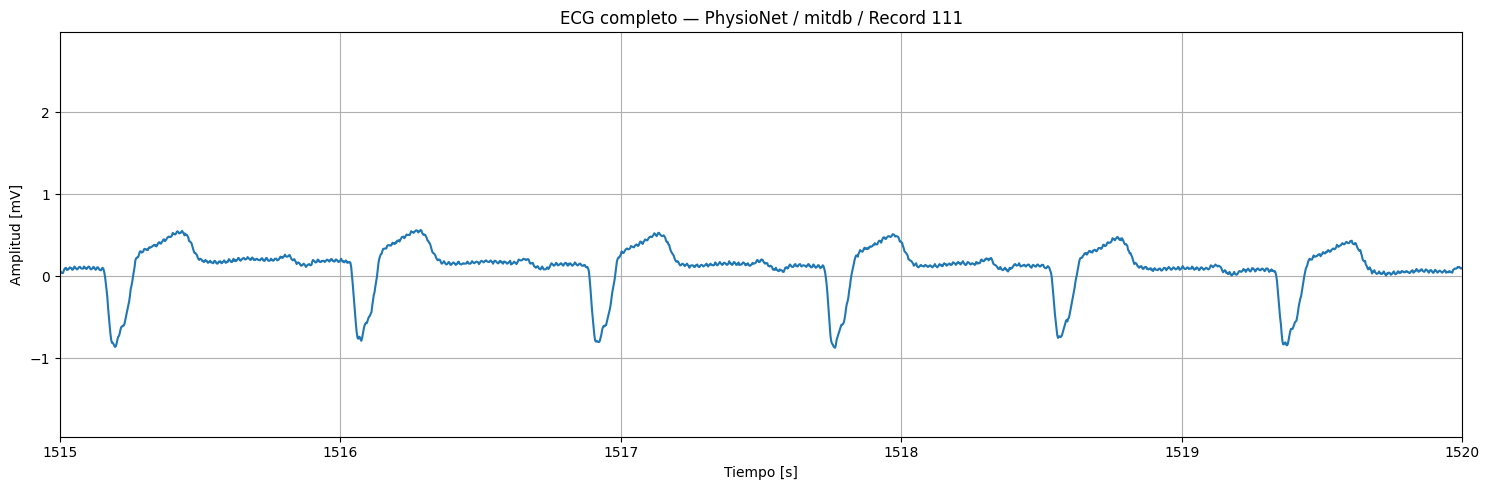

In [65]:

# ============================================
# GRÁFICA 1: ECG COMPLETO
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t, signal)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"ECG completo — PhysioNet / {DATABASE} / Record {RECORD}"
)

plt.grid(True)
plt.xlim(1515, 1520)
plt.tight_layout()
plt.show()





### Preguntas de análisis 2
**En base al registro 100 del canal 0:**
1. ¿La señal presenta una amplitud constante?
##### --> No, se observa un deriva leve que cambia la altura del mínimo y máximo en cada ciclo.
2. ¿Se pueden identificar visualmente complejos QRS?
##### --> Desde una ampliación x=[0,50], sí, sino se pierde entre tanta información en la gráfica
3. ¿La morfología permanece igual durante todo el registro?
#####--> Similar, porque se define claramente en la mayor porción de la señal el complejo QRS, y las ondas P y T
4. ¿Se observa ruido?
##### --> Un poco de ruido de alta frecuencia, pero baja amplitud, como Interferencia de corriente alterna (50/60 Hz).
5. ¿Qué ventajas tiene visualizar una señal durante varios minutos?
##### --> Se puede saber si hay un ruido de baja frecuencia, como de la red eléctrica, además de si se presentan alteraciones de la señal con una razón médica aparente más fundamentada
6. ¿Qué limitaciones tiene una gráfica demasiado extensa?
##### --> Se pierde el detalle morfológico de cada ciclo cardiaco en una vista completa




# 10. GRÁFICA 2 — Segmento ECG ampliado

Una señal completa puede dificultar el análisis de eventos individuales.

Por ello seleccionaremos solamente los primeros `DURATION` segundos.


In [66]:

# ============================================
# SELECCIONAR SEGMENTO
# ============================================

N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment = t[:N]

print(f"Duración solicitada : {DURATION} s")
print(f"Frecuencia muestreo : {fs} Hz")
print(f"Número de muestras  : {N}")


Duración solicitada : 10 s
Frecuencia muestreo : 360 Hz
Número de muestras  : 3600


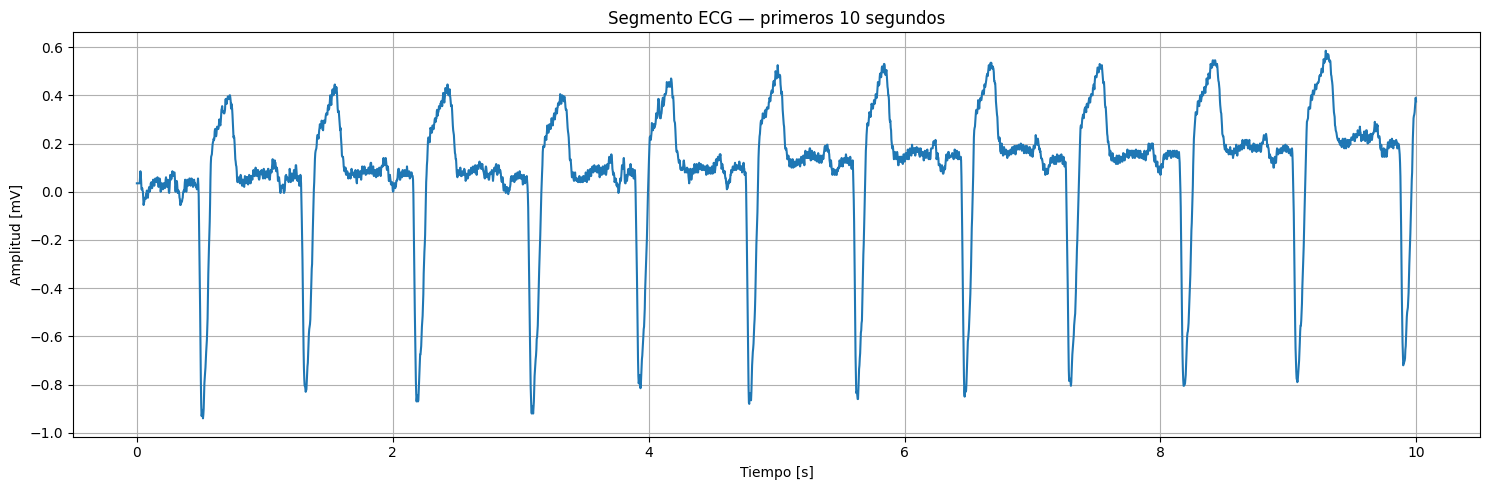

In [67]:

# ============================================
# GRÁFICA 2: SEGMENTO ECG
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t_segment, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Actividad

Observe cuidadosamente la gráfica.

Intente identificar:

- onda P;
- complejo QRS;
- onda T;
- intervalo entre complejos QRS;
- posibles artefactos.

> **Nota:** la identificación automática de ondas no forma parte de este laboratorio. Aquí el objetivo es desarrollar una primera capacidad de observación de señales biomédicas.



# 11. GRÁFICA 3 — Histograma de amplitudes

El histograma permite observar cómo se distribuyen los valores de amplitud de la señal.

Podemos utilizarlo para introducir conceptos como:

- media;
- dispersión;
- valores extremos;
- distribución de amplitudes.


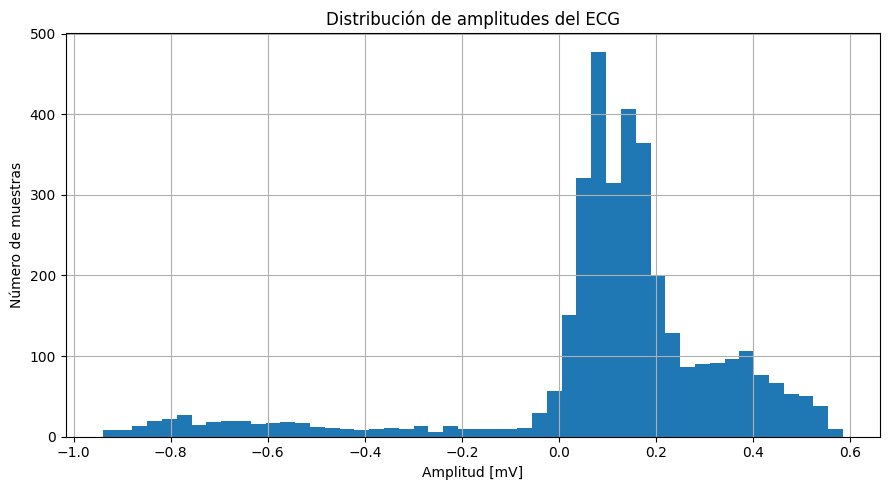

In [68]:

# ============================================
# GRÁFICA 3: HISTOGRAMA
# ============================================

plt.figure(figsize=(9, 5))

plt.hist(
    signal_segment,
    bins=50
)

plt.xlabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG")

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 3
**En base al registro 100 del canal 0:**

1. ¿Dónde se concentra la mayor cantidad de muestras?
#####--> En -0.35mV aproximadamente.

2. ¿La distribución parece simétrica?
#####--> No del todo, podría verse una leve asimetría positiva por los poquitos valores positivos que se registran.

3. ¿Existen valores extremos?
#####--> Sí, la mayoría rondean los 0.8mV
4. ¿Qué podría producir valores de amplitud muy diferentes al valor central?
#####--> Eventos fisiológicos reales como las ondas R y/o contracciones ventriculares prematuras (CVP), además de Artefactos y ruido técnico por movimiento brusco o mal contacto en electrodos.

5. ¿El histograma conserva información temporal? Explique.
#####--> No, solo se registra el conteo de la frecuencia con la que aparece cada amplitud específica. En este agrupamiento en barras, se pierde por completo el orden cronológico de los ciclos cardiacos.



# 12. GRÁFICA 4 — Representación discreta

Una señal digital no solamente puede representarse como una línea continua visualmente.

También podemos observar sus muestras individuales.

Esto permite introducir el concepto:

\[
x[n]
\]

donde `n` representa el índice de muestra.


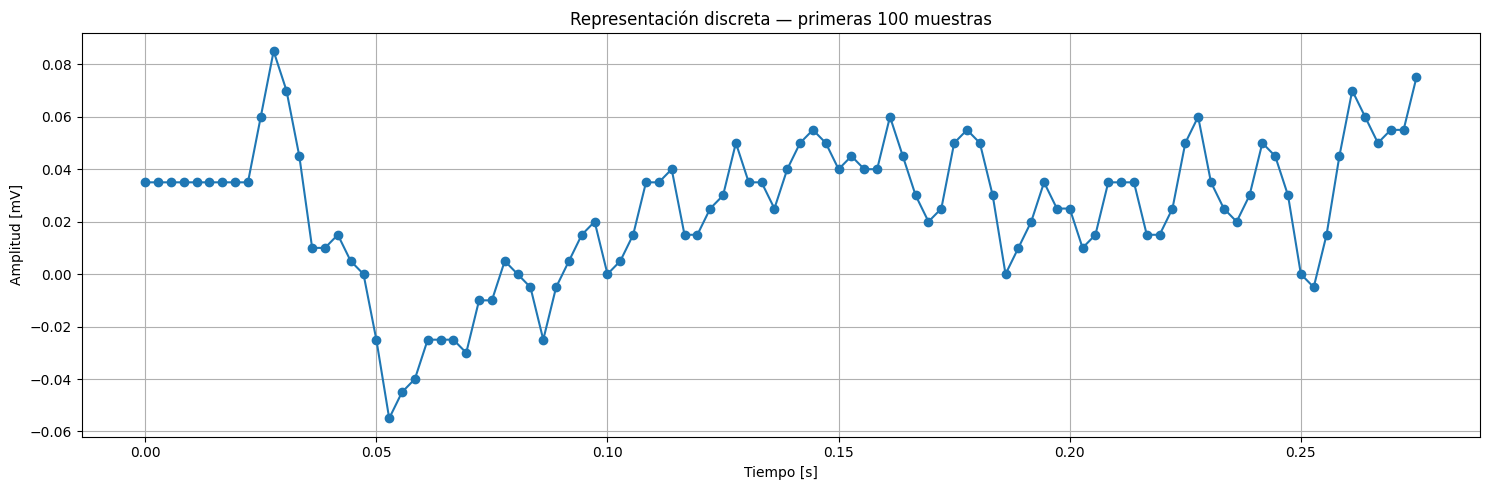

In [69]:

# ============================================
# GRÁFICA 4: MUESTRAS DISCRETAS
# ============================================

N_SAMPLES = 100

plt.figure(figsize=(15, 5))

plt.plot(
    t_segment[:N_SAMPLES],
    signal_segment[:N_SAMPLES],
    marker="o"
)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Representación discreta — primeras {N_SAMPLES} muestras"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 4

1. ¿Cuántas muestras existen por segundo?
#####--> 36 muestras en 0.1 segundos, por ende: 360 muestras/s
2. ¿Qué ocurre si aumentamos `fs`?
#####--> Se tendrán más muestras en un mismo lapso de tiempo, teniendo detalles más finos de la señal
3. ¿Qué ocurre si disminuimos `fs`?
#####--> Se tendrán menos muestras en un mismo lapso de tiempo, teniendo una reconstrucción de trazo más rudimentario
4. ¿Qué representa el eje `n` en una señal discreta?
#####--> El número de muestras tomadas de la señal
5. ¿Cuál es la relación entre `n`, `fs` y `t`?
#####--> $n*f_s = t$



# 13. Estadística básica de la señal

Antes de exportar la señal calcularemos algunos parámetros básicos.


In [70]:

# ============================================
# ESTADÍSTICAS BÁSICAS
# ============================================

mean_value = np.mean(signal_segment)
std_value = np.std(signal_segment)
min_value = np.min(signal_segment)
max_value = np.max(signal_segment)

print("ESTADÍSTICAS DEL SEGMENTO")
print("=" * 40)
print(f"Media             : {mean_value:.4f}")
print(f"Desviación estándar: {std_value:.4f}")
print(f"Mínimo            : {min_value:.4f}")
print(f"Máximo            : {max_value:.4f}")
print(f"Rango             : {max_value - min_value:.4f}")


ESTADÍSTICAS DEL SEGMENTO
Media             : 0.1019
Desviación estándar: 0.2692
Mínimo            : -0.9400
Máximo            : 0.5850
Rango             : 1.5250



# 14. Convertir ECG a archivo WAV

El formato WAV es común en aplicaciones de audio. Sin embargo, nuestra señal es un ECG.

Para poder almacenarla como WAV realizaremos:

```text
ECG original
     ↓
Eliminar componente media
     ↓
Normalizar amplitud
     ↓
Convertir a int16
     ↓
Guardar WAV
```

### ¿Por qué normalizar?

Los valores del ECG están expresados en unidades fisiológicas, mientras que el WAV suele utilizar representaciones enteras, como `int16`.

Utilizaremos el rango:

\[
-32768 \leq x \leq 32767
\]

para `int16`.


In [71]:

# ============================================
# PREPARAR ECG PARA WAV
# ============================================

ecg_for_wav = signal_segment.astype(float).copy()

# 1. Eliminar componente DC
ecg_for_wav = ecg_for_wav - np.mean(ecg_for_wav)

# 2. Normalizar
max_abs = np.max(np.abs(ecg_for_wav))

if max_abs == 0:
    raise ValueError("La señal no puede normalizarse porque todos sus valores son cero.")

ecg_normalized = ecg_for_wav / max_abs

# 3. Convertir a int16
ecg_int16 = np.int16(
    ecg_normalized * 32767
)

print("Conversión preparada correctamente.")
print(f"Tipo original   : {signal_segment.dtype}")
print(f"Tipo WAV        : {ecg_int16.dtype}")
print(f"Mínimo int16    : {ecg_int16.min()}")
print(f"Máximo int16    : {ecg_int16.max()}")


Conversión preparada correctamente.
Tipo original   : float64
Tipo WAV        : int16
Mínimo int16    : -32767
Máximo int16    : 15195



# 15. Guardar el archivo WAV

La frecuencia de muestreo del WAV será la misma frecuencia de muestreo del registro ECG.

Esto es importante porque permite conservar la separación temporal entre las muestras.


In [72]:

# ============================================
# GUARDAR WAV
# ============================================

wavfile.write(
    OUTPUT_WAV,
    int(fs),
    ecg_int16
)

print(f"Archivo WAV generado correctamente:")
print(OUTPUT_WAV)


Archivo WAV generado correctamente:
ecg_record_111_channel_1.wav



# 16. Reproducir el archivo WAV

En Google Colab/Jupyter podemos utilizar un reproductor integrado.


In [73]:

# Reproducir el archivo WAV

display(
    Audio(
        OUTPUT_WAV,
        rate=int(fs)
    )
)



### Preguntas de análisis 5

1. ¿Puede escuchar claramente la señal?

Se escucha la señal pero no claramente.

2. ¿El sonido corresponde a un sonido fisiológico real?

No exactamente. El sonido que se escucha es una representación de la señal eléctrica del corazón convertida a audio. Por lo tanto, no corresponde directamente a un sonido fisiológico producido por el cuerpo, sino a una señal ECG transformada para poder reproducirse.

3. ¿Por qué un ECG puede convertirse a WAV?

Un ECG puede convertirse a WAV porque ambos pueden representarse como señales digitales. Al convertir los valores del ECG a un formato de audio, es posible reproducir sus variaciones mediante un dispositivo de sonido y analizar auditivamente algunos cambios de la señal.

4. ¿Qué información se conserva al hacer la conversión?

Se conservan las variaciones de amplitud de la señal y su evolución en el tiempo, siempre que la conversión se realice correctamente.

5. ¿Qué información fisiológica podría perderse al escucharla?

Al escucharla se puede perder información relacionada con la morfología del ECG, como la forma de las ondas P, el complejo QRS y la onda T.

6. ¿Qué diferencia existe entre representar un ECG gráficamente y reproducirlo como audio?

Al graficar el ECG es posible visualizar con mayor claridad su amplitud, duración, forma de las ondas y comportamiento durante cada ciclo cardíaco. Por otro lado, al escucharlo como audio, estas características se perciben únicamente mediante cambios en el sonido, lo que dificulta analizar con precisión la información fisiológica de la señal.



# 17. Descargar el archivo WAV

En Google Colab se puede descargar el archivo generado.


In [74]:

# ============================================
# DESCARGAR WAV EN GOOGLE COLAB
# ============================================

try:
    from google.colab import files
    files.download(OUTPUT_WAV)
except ImportError:
    print("Este entorno no es Google Colab.")
    print(f"El archivo está disponible localmente como: {OUTPUT_WAV}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


# 18. Ejercicios propuestos

## Ejercicio 1 — Cambiar de registro

Modifique:

```python
RECORD = "100"
```

por otro registro válido de la misma base de datos.

Compare:

- frecuencia de muestreo;
- número de canales;
- nombres de canales;
- morfología;
- amplitud;
- distribución.



### Entregable

Incluya una captura o las cuatro gráficas del nuevo registro y escriba una comparación con el registro original.

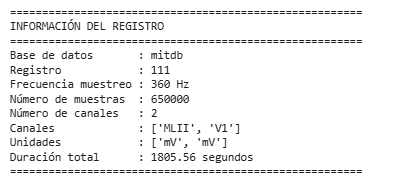

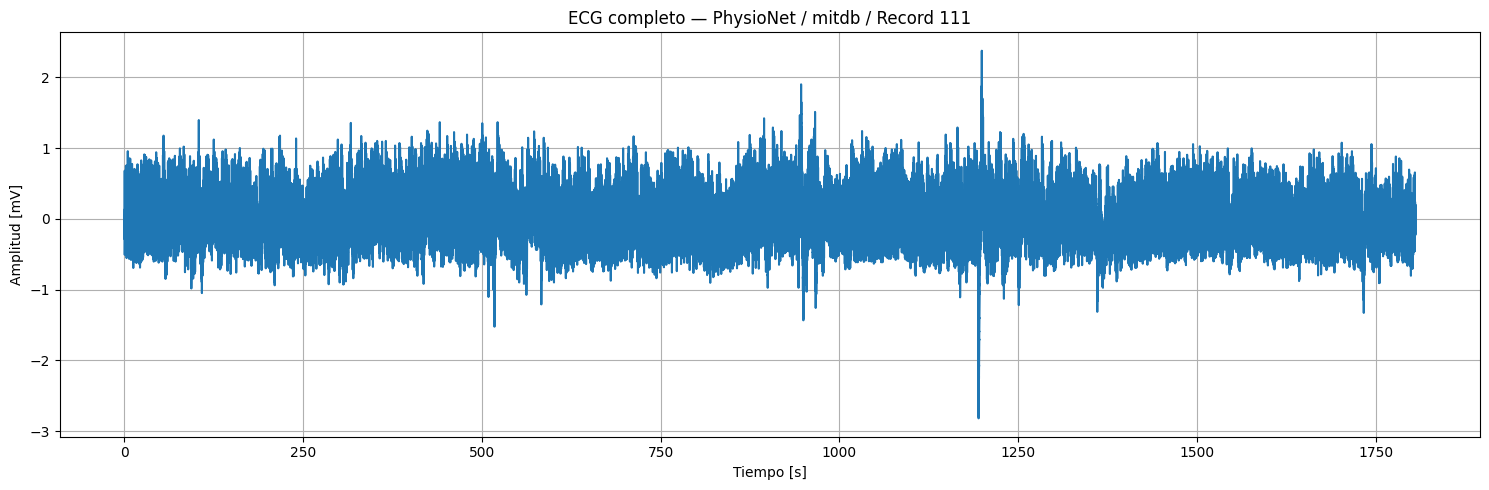

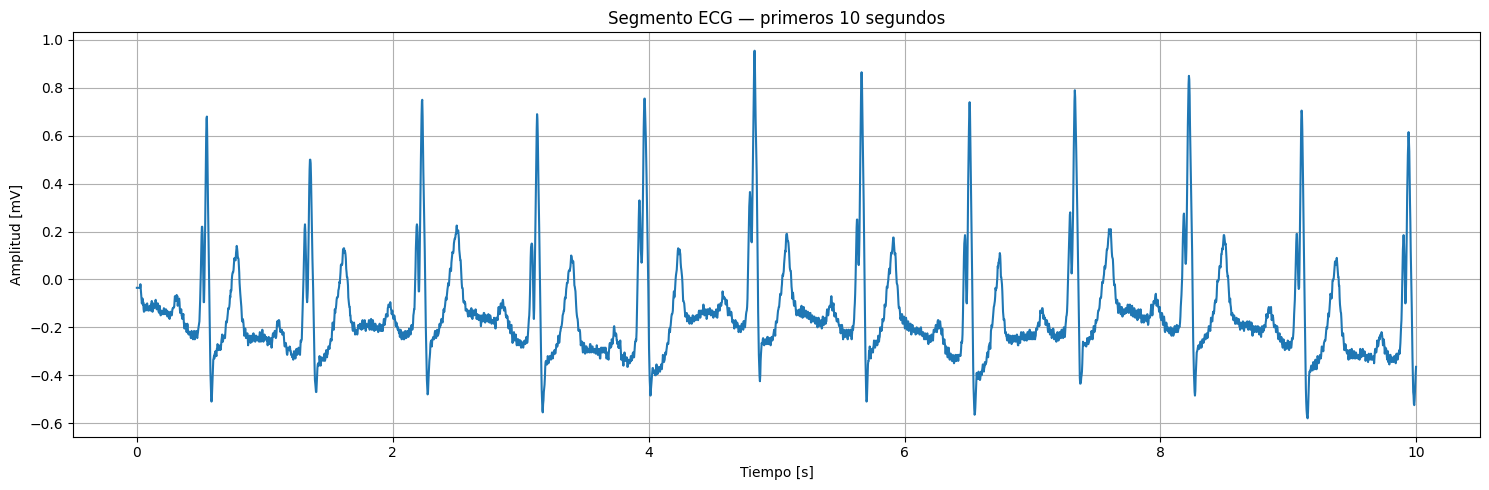
---

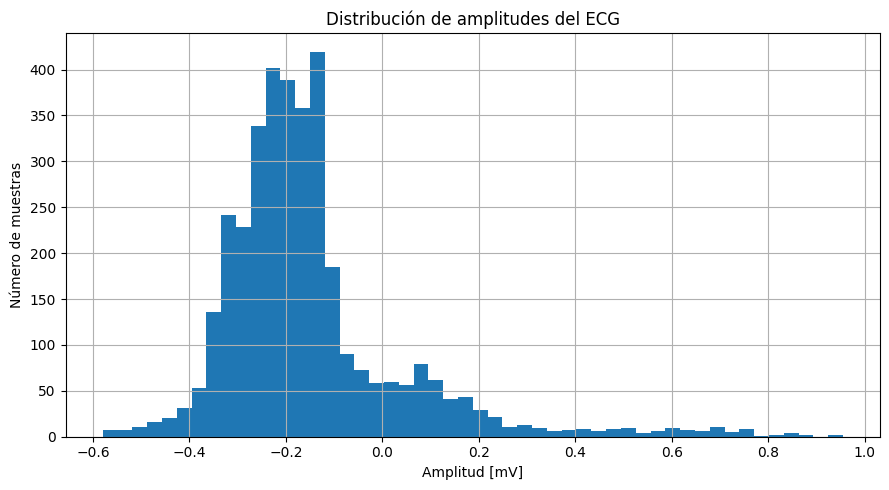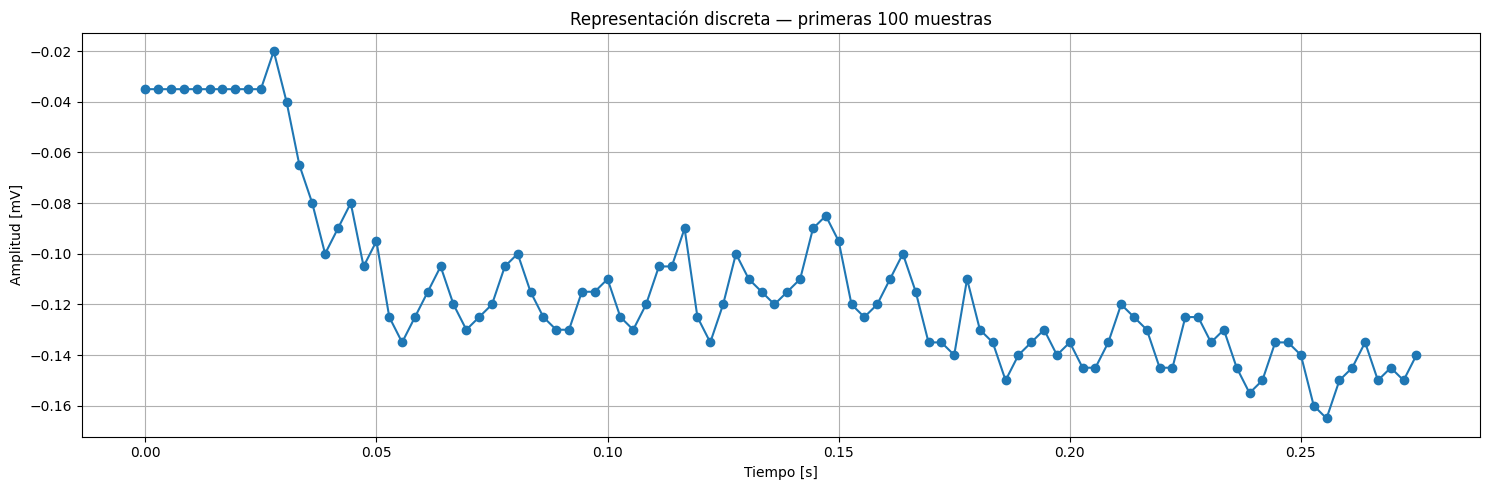

## Ejercicio 2 — Cambiar de canal

Modifique:

```python
CHANNEL = 0
```

por otro canal disponible.

**Canal 1:**
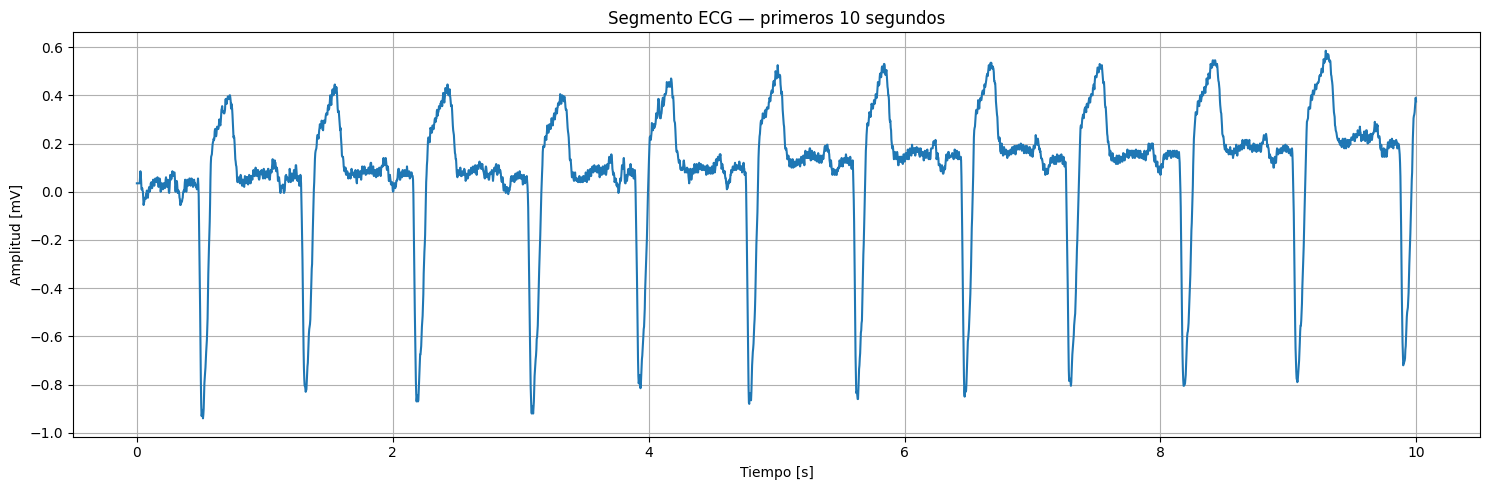

Responda:

1. ¿Qué nombre tiene el nuevo canal? V5
2. ¿Tiene las mismas unidades? Si, mV
3. ¿La morfología es igual? No tienen la misma morfología porque miran el corazón desde planos geométricos diferentes.
4. ¿Qué diferencias observa? Las diferencias morfológicas principales entre MLII y V5 radican en que MLII muestra una onda P más alta y nítida, una onda S final más profunda y carece de onda Q inicial en condiciones normales. Por el contrario, V5 presenta una onda P más pequeña, una onda Q septal pequeña pero muy común al inicio del complejo, una onda R con un voltaje mucho más alto debido a la cercanía del electrodo con la masa del ventrículo izquierdo, y una onda S final prácticamente inexistente.

---

## Ejercicio 3 — Cambiar la duración

Pruebe:

```python
DURATION = 5
```

```python
DURATION = 20
```

y compare las visualizaciones.

**DURATION=5s:**
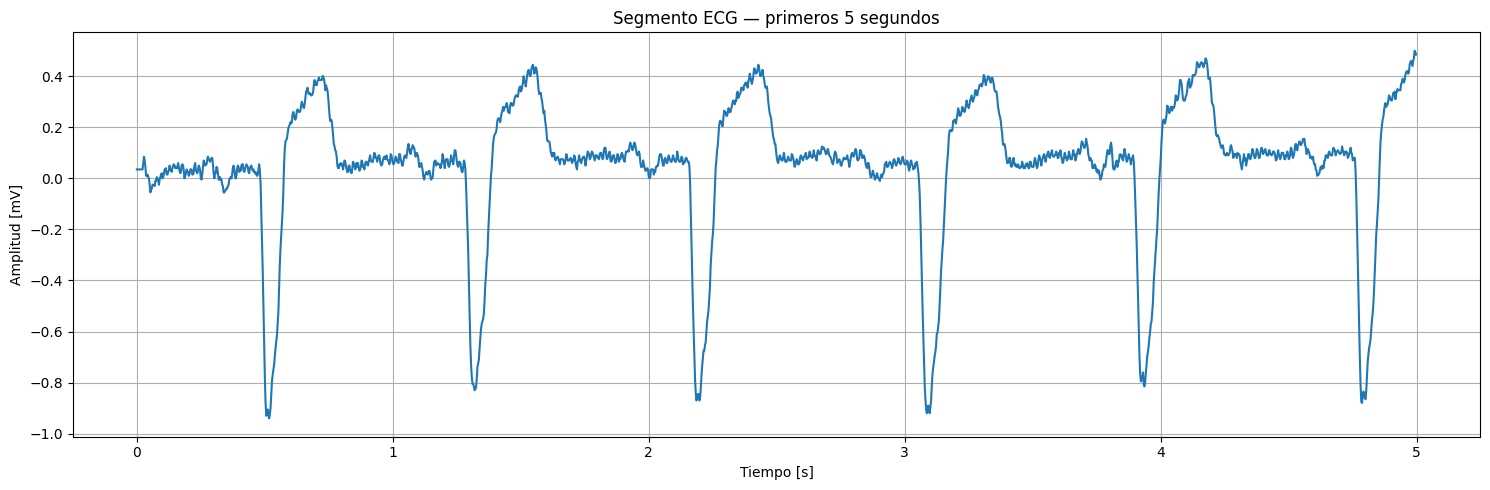

**DURATION=10s:**
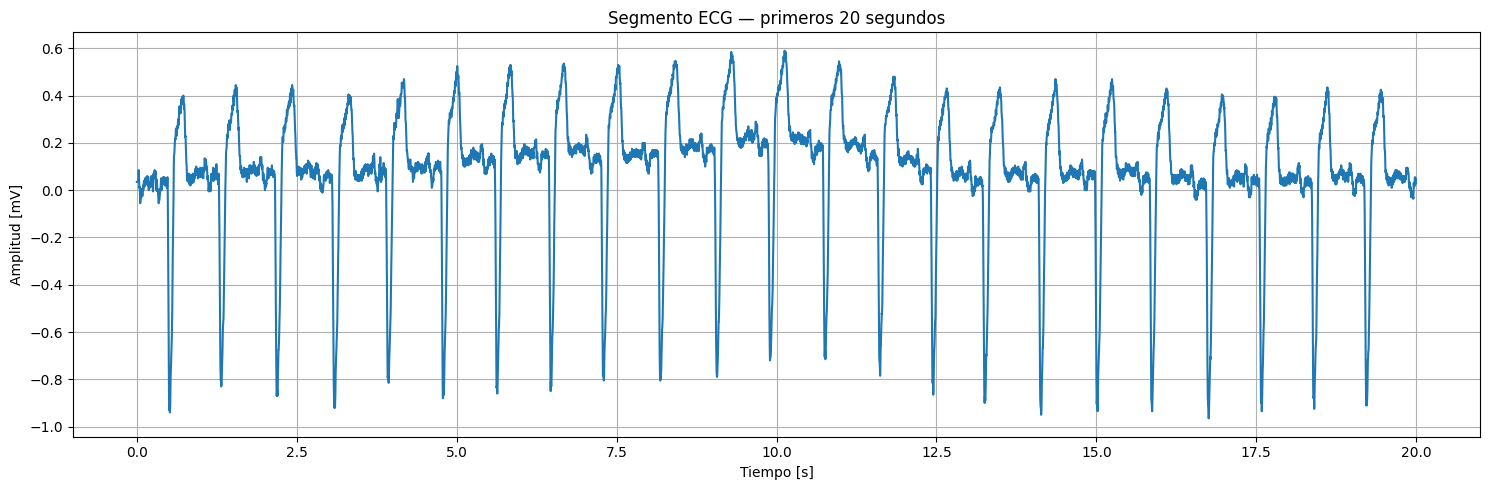

Explique por qué una duración demasiado pequeña o demasiado grande puede dificultar el análisis.
#####-->Una duración demasiado pequeña puede dificultar el análisis porque no permite observar suficientes ciclos cardíacos para identificar con claridad la frecuencia cardíaca, la regularidad del ritmo y posibles alteraciones. Por otro lado, una duración demasiado grande genera una cantidad excesiva de datos, haciendo más difícil su visualización y aumentando el tiempo y los recursos necesarios para procesarlos.
Por ello, es importante seleccionar una duración adecuada que permita obtener suficiente información del ECG sin generar datos innecesarios.


## Ejercicio 4 — Frecuencia de muestreo

Suponga que:

\[
f_s = 360\ Hz
\]

### a)

Calcule el periodo de muestreo:

\[
T_s = \frac{1}{f_s}
\]
T_s=2.78 ms
### b)

¿Cuántas muestras existen en 5 segundos?
Hay 1800 muestras en 5 segundos

### c)

¿Cuántas muestras existen en 10 segundos?
Hay 3600 muestras en 10 s.

### d)

Explique qué sucedería si la frecuencia de muestreo fuese reducida significativamente. Si la frecuancia de muestreo se reduce eso quiere decir que habría menor numero de muestras en toda la señal por lo que correria el riesgo de perdida de la información de la función.


---

## Ejercicio 5 — Análisis de amplitud

Utilizando el segmento seleccionado:

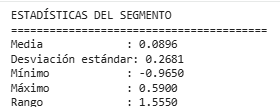

1. Calcule la media.
Representa el valor promedio de amplitud de todas las muestras del segmento. Permite conocer aproximadamente el nivel central de la señal. Media=0.0896
2. Calcule la desviación estándar.
Indica cuánto se dispersan los valores de amplitud respecto a la media.
3. Determine el máximo.
Corresponde al valor de amplitud más alto encontrado en el segmento. Permite identificar el punto de mayor amplitud positiva.
4. Determine el mínimo.
Valor de amplitud más bajo. En este caso es −0.9650 mV, representando la mayor amplitud negativa registrada.
5. Calcule el rango
Diferencia entre el máximo y el mínimo:
Rango = 0.5900 − (−0.9650) = 1.5550 mV

Indica la extensión total de valores de amplitud que presenta la señal.
Explique qué información proporciona cada parámetro.



# 19. Preguntas conceptuales

Responda con sus propias palabras.

### 1.
¿Qué es PhysioNet?

PhysioNet es una plataforma que permite acceder a bases de datos de señales fisiológicas reales, como señales ECG. En este laboratorio se utiliza para obtener registros de la MIT-BIH Arrhythmia Database.

### 2.
¿Qué diferencia existe entre `DATABASE` y `RECORD`?

`DATABASE` indica la base de datos de donde se obtiene la señal, mientras que `RECORD` identifica el registro específico dentro de esa base de datos. Por ejemplo, DATABASE = "mitdb" y RECORD = "111" permiten identificar el registro 111 de la base MIT-BIH.

### 3.
¿Qué representa `fs`?

La frecuencia de muestreo.

### 4.
¿Qué representa `CHANNEL`?

El canal seleccionado que se desea analizar.

### 5.
¿Qué representa `record.p_signal`?

`record.p_signal` contiene las muestras de las señales fisiológicas del registro. Las filas representan las muestras tomadas y las columnas representan los diferentes canales.

### 6.
¿Por qué necesitamos construir un eje temporal?

Lo necesitamos ya que el eje temporal permite relacionar cada muestra con un instante determinado y visualizar cómo cambia la señal con el tiempo.

### 7.
¿Qué diferencia existe entre una señal continua y una señal discreta?

Una señal continua puede tomar valores en cualquier instante de tiempo, mientras que una señal discreta está representada mediante muestras tomadas en instantes específicos.

### 8.
¿Por qué no debemos interpretar directamente un archivo WAV como si fuera una señal ECG?

Porque el WAV es solamente un formato utilizado para almacenar y reproducir la señal. Aunque el ECG puede convertirse a WAV, esto no significa que sea originalmente una señal de audio. Además, al reproducirla como sonido se puede perder la interpretación fisiológica que se obtiene al observar su forma de onda.

### 9.
¿Qué ventajas ofrece trabajar con señales biomédicas reales en lugar de señales sintéticas?

Las señales reales permiten trabajar con características propias de las mediciones fisiológicas, como variaciones de amplitud, cambios de morfología y posibles alteraciones que no siempre están presentes en señales sintéticas.

### 10.
¿Qué dificultades encontró durante el laboratorio?

Al principio, el mayor reto fue entender la estructura de PhysioNet en cuanto a la organización de registros, canales y muestras. Asimismo, generó cierta confusión asociar la frecuencia de muestreo con el eje temporal, así como distinguir claramente entre la señal ECG nativa y su versión convertida a formato WAV.


# 20. Reto final

Seleccione un registro diferente y realice el siguiente análisis:

```text
PhysioNet
   ↓
Seleccionar RECORD
   ↓
Identificar canales
   ↓
Seleccionar canal ECG
   ↓
Analizar 10 segundos
   ↓
Gráfica ECG
   ↓
Histograma
   ↓
Representación discreta
   ↓
Estadística
   ↓
Exportar WAV
```

### Informe

Presente:

1. Identificación de la base de datos.
2. Identificación del registro.
3. Frecuencia de muestreo.
4. Canal seleccionado.
5. Duración analizada.
6. Las 4 gráficas.
7. Estadísticas.
8. Archivo WAV.
9. Interpretación de los resultados.
10. Conclusiones.



# 21. Conclusiones esperadas

Al finalizar el laboratorio, el estudiante debería comprender que una señal biomédica puede estudiarse desde diferentes perspectivas:

```text
              SEÑAL ECG
                  │
       ┌──────────┼──────────┐
       ↓          ↓          ↓
     Tiempo    Amplitud   Distribución
       │          │          │
       └──────────┼──────────┘
                  ↓
          Señal discreta x[n]
                  ↓
          Procesamiento digital
                  ↓
        Filtros FIR / IIR
                  ↓
         Análisis de señales
```

Este laboratorio constituye la base para los siguientes laboratorios, donde se aplicarán técnicas de **procesamiento digital de señales**, incluyendo filtros FIR, filtros IIR, respuesta en frecuencia y Transformada Z.



# Referencias

- PhysioNet — plataforma de acceso a bases de datos de señales fisiológicas.
- WFDB Python — herramientas Python para lectura y procesamiento de registros fisiológicos.
- MIT-BIH Arrhythmia Database — base de datos utilizada como ejemplo en este laboratorio.

**Nota:** consulte siempre la documentación oficial de la base de datos seleccionada para conocer el significado de sus registros, canales y anotaciones.
